# ANALYSIS OF EMBEDDING SPACE 

In this notebook, we train a small encoder-decoder Transformer to analyse the primitive schemas learned in the previous notebook [IM_Tutorial_03.ipynb](IM_Tutorial_03.ipynb). 

We generate a figure withe projections of the embedding space that show that the tokens are organized in the embedding space according to their meaning to the agent. 

# Load the training data

In [1]:
train_data = [[[15, 22, 2], [2, 2, 0, 12, 22, 2, 4]], [[2, 2, 0, 12, 22, 2, 4], [1, 1, 1]], [[2, 2, 0], [12, 22, 2, 4, 1, 1, 1]], [[22, 2, 2, 2, 0], [12, 22, 2, 4, 1, 1, 1]], [[2, 2, 0, 12, 22, 2, 4], [1, 1, 1, 6]], [[1, 1, 1, 1, 6], [1, 1, 1, 1, 3]], [[1, 1, 1, 1], [6, 1, 1, 1, 1, 3]], [[1, 1, 1, 1, 1], [6, 1, 1, 1, 1, 3]], [[1, 1, 1, 1, 6], [1, 1, 1, 1, 3, 15, 21]], [[10, 27, 2, 2, 4], [1, 1, 1, 1, 3]], [[1, 1, 1, 3, 11], [26, 6, 1, 1, 1, 3]], [[5, 10], [26, 6, 1, 1, 1, 1, 1, 10]], [[10, 26], [6, 1, 1, 1, 1, 1, 10, 26]], [[6, 1, 1, 1, 1, 1, 10, 26], [6, 1, 1, 1, 1, 1, 12]], [[6, 1, 1, 1, 1, 1, 10], [26, 6, 1, 1, 1, 1, 1, 12]], [[26, 6, 1, 1, 1, 1, 1, 10], [26, 6, 1, 1, 1, 1, 1, 12]], [[26, 6, 1, 1, 1, 1, 1, 12], [22, 0]], [[26], [6, 1, 1, 1, 1, 1, 12, 22, 0]], [[6, 1, 1, 1, 1, 1, 10, 26], [6, 1, 1, 1, 1, 1, 12, 22, 0]], [[6, 1, 1, 1, 1, 1, 12, 22, 0], [12]], [[6, 1, 1, 1, 1, 1, 12], [22, 0, 12]], [[26, 6, 1, 1, 1, 1, 1, 12], [22, 0, 12]], [[6, 1, 1, 1, 1, 1, 12, 22, 0], [12, 22, 2, 2]], [[1, 1, 0, 12], [22, 2, 2, 2, 2, 2, 0]], [[22, 2, 2, 2, 2, 2, 0], [12, 22, 4]], [[12, 22, 4], [1, 6, 1, 1, 1, 1, 3]], [[22, 4, 1, 6], [1, 1, 1, 1, 3, 21]], [[1, 1, 1, 1, 3, 21], [1, 1, 1, 11, 6, 1]], [[1, 1, 1, 1, 3], [21, 1, 1, 1, 11, 6, 1]], [[1, 6, 1, 1, 1, 1, 3], [21, 1, 1, 1, 11, 6, 1]], [[1, 1, 1, 1, 3, 21], [1, 1, 1, 11, 6, 1, 21]], [[1, 1, 1, 11, 6, 1, 21], [1, 1, 1, 11, 6, 1, 21]], [[1, 1, 1, 11, 6, 1], [21, 1, 1, 1, 11, 6, 1, 21]], [[21, 1, 1, 1, 11, 6, 1], [21, 1, 1, 1, 11, 6, 1, 21]], [[1, 1, 1, 11, 6, 1, 21], [1, 1, 1, 11, 6, 1, 22]], [[21, 1, 1, 1, 11, 6, 1, 21], [1, 1, 1, 11, 6, 1, 22]], [[21], [1, 1, 1, 11, 6, 1, 21, 1, 1, 1, 11, 6, 1, 22]], [[1, 1, 1, 11, 6, 1, 21, 1, 1, 1, 11, 6, 1, 22], [2, 0]], [[1, 1, 1, 11, 6, 1, 21], [1, 1, 1, 11, 6, 1, 22, 2, 0]], [[21, 1, 1, 1, 11, 6, 1, 21], [1, 1, 1, 11, 6, 1, 22, 2, 0]], [[1, 1, 1, 11, 6, 1, 22, 2, 0], [12]], [[1, 1, 1, 11, 6, 1, 22], [2, 0, 12]], [[1, 1, 1, 11, 6, 1, 21, 1, 1, 1, 11, 6, 1, 22], [2, 0, 12]], [[2, 0, 12], [22, 2, 2, 2, 2, 2, 2]], [[2, 0], [12, 22, 2, 2, 2, 2, 2, 2]], [[1, 1, 1, 11, 6, 1, 22, 2, 0], [12, 22, 2, 2, 2, 2, 2, 2]], [[22, 2, 2, 2, 2, 2, 2], [2, 2, 2, 0]], [[12, 22, 2, 2, 2, 2, 2, 2], [2, 2, 2, 0]], [[12], [22, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0]], [[2, 0, 12], [22, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0]], [[22, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0], [12]], [[22, 2, 2, 2, 2, 2, 2], [2, 2, 2, 0, 12]], [[12, 22, 2, 2, 2, 2, 2, 2], [2, 2, 2, 0, 12]], [[2, 2, 2, 0, 12], [22, 2, 2, 2, 0]], [[2, 2, 2, 0], [12, 22, 2, 2, 2, 0]], [[22, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0], [12, 22, 2, 2, 2, 0]], [[2, 2, 2, 0, 12], [22, 2, 2, 2, 0, 12, 22, 4]], [[22, 2, 2, 2, 0, 12, 22, 4], [1, 5]], [[22, 2, 2, 2, 0], [12, 22, 4, 1, 5]], [[12, 22, 2, 2, 2, 0], [12, 22, 4, 1, 5]], [[22, 2, 2, 2, 0, 12, 22, 4], [1, 5, 26]], [[10], [26, 6, 1, 1, 1, 1, 1, 10, 26]], [[5, 10], [26, 6, 1, 1, 1, 1, 1, 10, 26]], [[6, 1, 1, 1, 1, 1, 10, 26], [6, 1, 1, 1, 1, 1, 11]], [[26, 6, 1, 1, 1, 1, 1, 10, 26], [6, 1, 1, 1, 1, 1, 11]], [[26], [6, 1, 1, 1, 1, 1, 10, 26, 6, 1, 1, 1, 1, 1, 11]], [[10, 26], [6, 1, 1, 1, 1, 1, 10, 26, 6, 1, 1, 1, 1, 1, 11]], [[6, 1, 1, 1, 1, 1, 10, 26, 6, 1, 1, 1, 1, 1, 11], [6, 1]], [[6, 1, 1, 1, 1, 1, 10, 26], [6, 1, 1, 1, 1, 1, 11, 6, 1]], [[26, 6, 1, 1, 1, 1, 1, 10, 26], [6, 1, 1, 1, 1, 1, 11, 6, 1]], [[6, 1, 1, 1, 1, 1, 11, 6, 1], [21]], [[6, 1, 1, 1, 1, 1, 11], [6, 1, 21]], [[6, 1, 1, 1, 1, 1, 10, 26, 6, 1, 1, 1, 1, 1, 11], [6, 1, 21]], [[6, 1, 1, 1, 1, 1, 11, 6, 1], [21, 1, 1, 3]], [[1, 1, 3, 21], [1, 1, 1, 11, 6, 1, 21]], [[1, 1, 3], [21, 1, 1, 1, 11, 6, 1, 21]], [[21, 1, 1, 3], [21, 1, 1, 1, 11, 6, 1, 21]], [[1, 1, 1, 11, 6, 1, 21], [1, 1, 3]], [[21, 1, 1, 1, 11, 6, 1, 21], [1, 1, 3]], [[21], [1, 1, 1, 11, 6, 1, 21, 1, 1, 3]], [[1, 1, 3, 21], [1, 1, 1, 11, 6, 1, 21, 1, 1, 3]], [[1, 1, 1, 11, 6, 1, 21, 1, 1, 3], [26]], [[1, 1, 1, 11, 6, 1, 21], [1, 1, 3, 26]], [[21, 1, 1, 1, 11, 6, 1, 21], [1, 1, 3, 26]]]

In [2]:
len(train_data)

84

## List of unique codes

In [3]:
import numpy as np
# Flatten manually then apply np.unique
flat = np.concatenate([np.concatenate(group) for group in train_data])
vocabulary = np.unique(flat).tolist()

print("Vocabulary:", vocabulary, "Size:", len(vocabulary))

Vocabulary: [0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 15, 21, 22, 26, 27] Size: 15


## Prepare the tokens

The code of sensorimotor loops are converted into tokens numbered consecutively.

In [20]:
import pandas as pd

BASE = 5
action_labels = ["forward", "sniff-front", "sniff-left", "sniff-right", "turn-left", "turn-right"]
outcome_labels = ["decrease", "stable", "increase", "bump", "eat"]
markers = ['diamond', 'square', 'square', 'square', 'circle', 'circle']
colors = ['#535865', '#D6D6D6', '#FAE2DB', '#F93943', '#E365C1']  # Style notebook
colors = ['#D6D6D6', '#D0FFD0', '#A0FFA0', '#F93943', '#00FF00']  # Style AIRIS
tags = ['forward', 'front', 'left', 'right', 'left', 'right']
directions = ['front', 'front', 'left', 'right', 'left', 'right']
objects = ["wall", "empty", "empty", "wall", "eat"]

data = {'code': vocabulary,
        'label': [f"⟨{action_labels[i//BASE]},{outcome_labels[i%BASE]}⟩" for i in vocabulary], 
        'symbol': [markers[i//BASE] for i in vocabulary],
        'color' : [colors[i%BASE] for i in vocabulary],
        'tag' : [tags[i//BASE] for i in vocabulary], 
        'direction' : [directions[i//BASE] for i in vocabulary],
        'object': [objects[i%BASE] for i in vocabulary]}
df = pd.DataFrame(data)

df

,code,label,symbol,color,tag,direction,object
0,0,"⟨forward,decrease⟩",diamond,#D6D6D6,forward,front,wall
1,1,"⟨forward,stable⟩",diamond,#D0FFD0,forward,front,empty
2,2,"⟨forward,increase⟩",diamond,#A0FFA0,forward,front,empty
3,3,"⟨forward,bump⟩",diamond,#F93943,forward,front,wall
4,4,"⟨forward,eat⟩",diamond,#00FF00,forward,front,eat
5,5,"⟨sniff-front,decrease⟩",square,#D6D6D6,front,front,wall
6,6,"⟨sniff-front,stable⟩",square,#D0FFD0,front,front,empty
7,10,"⟨sniff-left,decrease⟩",square,#D6D6D6,left,left,wall
8,11,"⟨sniff-left,stable⟩",square,#D0FFD0,left,left,empty
9,12,"⟨sniff-left,increase⟩",square,#A0FFA0,left,left,empty


## The sequences of tokens

Generate the training sequences by substitute the codes with the token index.


In [22]:
# Give the number of the token from the number of the sensorimotor code
code_to_index = {code: idx for idx, code in enumerate(df['code'])}

# Substitue the code with the index in the training data
train_token = []
for l1 in train_data:
    train_l1 = []
    for l2 in l1:
        train_l2 = []
        for l3 in l2:
            train_l2.append(code_to_index[l3])
        train_l1.append(train_l2)
    train_token.append(train_l1)            


# Create a small encoder-decoder tranformer model

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# --- Configuration ---

VOCAB_SIZE = len(vocabulary) + 3
SOS_TOKEN = len(vocabulary) 
EOS_TOKEN = len(vocabulary) + 1
PAD_TOKEN = len(vocabulary) + 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOCAB_SIZE

18

In [9]:
# --- 1. Dataset & DataLoader ---

class Seq2SeqDataset(Dataset):
    def __init__(self, sequences):
        self.data = []
        for src, tgt in sequences:
            tgt_input = [SOS_TOKEN] + tgt
            tgt_output = tgt + [EOS_TOKEN]
            self.data.append((torch.tensor(src), torch.tensor(tgt_input), torch.tensor(tgt_output)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    src_batch, tgt_in_batch, tgt_out_batch = zip(*batch)

    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_TOKEN)
    tgt_in_padded = pad_sequence(tgt_in_batch, batch_first=True, padding_value=PAD_TOKEN)
    tgt_out_padded = pad_sequence(tgt_out_batch, batch_first=True, padding_value=PAD_TOKEN)

    return src_padded, tgt_in_padded, tgt_out_padded

def get_dataloader(sequences, batch_size=32):
    dataset = Seq2SeqDataset(sequences)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)


In [10]:
# --- 2. Transformer Model ---

class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_TOKEN)
        self.pos_encoding = nn.Parameter(torch.randn(32, d_model))  # max sequence length

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead)

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.output_linear = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt_in, src_key_padding_mask, tgt_key_padding_mask, tgt_mask):
        src_emb = self.embedding(src) + self.pos_encoding[:src.size(1)]
        tgt_emb = self.embedding(tgt_in) + self.pos_encoding[:tgt_in.size(1)]

        src_emb = src_emb.permute(1, 0, 2)  # (seq, batch, embed)
        tgt_emb = tgt_emb.permute(1, 0, 2)

        memory = self.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)
        out = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        out = self.output_linear(out)
        return out.permute(1, 0, 2)  # (batch, seq, vocab)

    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
        return mask.to(DEVICE)


In [11]:
# --- 3. Training function ---

def train_model(model, dataloader, num_epochs=10):
    model.train()
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for src, tgt_in, tgt_out in dataloader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)

            src_pad_mask = (src == PAD_TOKEN)
            tgt_pad_mask = (tgt_in == PAD_TOKEN)
            tgt_mask = model.generate_square_subsequent_mask(tgt_in.size(1))

            output = model(src, tgt_in, src_pad_mask, tgt_pad_mask, tgt_mask)

            loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            # Accuracy computation
            predicted = output.argmax(dim=-1)  # (batch_size, seq_len)
            mask = (tgt_out != PAD_TOKEN)
            correct += (predicted == tgt_out).masked_select(mask).sum().item()
            total += mask.sum().item()

        accuracy = 100 * correct / total if total > 0 else 0
        print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")


In [12]:
# --- 4. Generation Function ---

def generate_sequence(model, input_sequence, max_len=50):
    model.eval()
    src = torch.tensor([input_sequence], dtype=torch.long).to(DEVICE)
    src_pad_mask = (src == PAD_TOKEN)
    src_emb = model.embedding(src) + model.pos_encoding[:src.size(1)]
    memory = model.encoder(src_emb.permute(1, 0, 2), src_key_padding_mask=src_pad_mask)

    generated = [SOS_TOKEN]
    for _ in range(max_len):
        tgt = torch.tensor([generated], dtype=torch.long).to(DEVICE)
        tgt_pad_mask = (tgt == PAD_TOKEN)
        tgt_mask = model.generate_square_subsequent_mask(tgt.size(1))

        tgt_emb = model.embedding(tgt) + model.pos_encoding[:tgt.size(1)]
        out = model.decoder(
            tgt_emb.permute(1, 0, 2),
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )
        logits = model.output_linear(out[-1])
        next_token = torch.argmax(logits, dim=-1).item()
        if next_token == EOS_TOKEN:
            break
        generated.append(next_token)
    return generated[1:]  # remove <sos>


# Let's train the model

In [13]:
torch.manual_seed(0)

dataloader = get_dataloader(train_token, batch_size=32)
model = SimpleTransformer(VOCAB_SIZE, d_model=32).to(DEVICE)

C:\Users\ogeorgeon\AppData\Local\Temp\ipykernel_2972\1912181017.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [14]:
train_model(model, dataloader, num_epochs=50)

C:\Users\ogeorgeon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 1, Loss: 7.7461, Accuracy: 22.83%
Epoch 2, Loss: 6.1422, Accuracy: 39.00%
Epoch 3, Loss: 5.7867, Accuracy: 40.17%
Epoch 4, Loss: 5.4792, Accuracy: 49.33%
Epoch 5, Loss: 5.1051, Accuracy: 53.67%
Epoch 6, Loss: 4.8049, Accuracy: 58.17%
Epoch 7, Loss: 4.6228, Accuracy: 60.00%
Epoch 8, Loss: 4.4066, Accuracy: 62.50%
Epoch 9, Loss: 4.2791, Accuracy: 62.83%
Epoch 10, Loss: 4.0958, Accuracy: 63.00%
Epoch 11, Loss: 3.9010, Accuracy: 63.83%
Epoch 12, Loss: 3.7808, Accuracy: 64.33%
Epoch 13, Loss: 3.7249, Accuracy: 65.67%
Epoch 14, Loss: 3.5908, Accuracy: 66.17%
Epoch 15, Loss: 3.4540, Accuracy: 66.83%
Epoch 16, Loss: 3.2883, Accuracy: 69.00%
Epoch 17, Loss: 3.2669, Accuracy: 68.67%
Epoch 18, Loss: 3.1108, Accuracy: 71.00%
Epoch 19, Loss: 2.9964, Accuracy: 71.83%
Epoch 20, Loss: 2.9782, Accuracy: 72.00%
Epoch 21, Loss: 2.8297, Accuracy: 72.50%
Epoch 22, Loss: 2.7900, Accuracy: 72.33%
Epoch 23, Loss: 2.6276, Accuracy: 72.50%
Epoch 24, Loss: 2.5945, Accuracy: 75.00%
Epoch 25, Loss: 2.5125, A

# Visualize the embedding

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
# import plotly.io as pio
# pio.renderers.default = "notebook"  # or "plotly_mimetype", "iframe"

# Liste de formes de marqueurs disponibles dans Plotly
marker_symbols = df['symbol'].tolist()
marker_colors = df['color'].tolist()
marker_tags = df['tag'].tolist()

def plotly_embedding(embedding_weights, all_labels, all_tokens):
    # Extraire les vecteurs d'embedding
    # embedding_weights = agent._lstm.embedding.weight.data        
    # Récupérer les coordonnées
    x = embedding_weights[:, 0].detach().numpy()
    y = embedding_weights[:, 1].detach().numpy()
    z = embedding_weights[:, 2].detach().numpy()
    #labels = [f"Token {i}" for i in range(agent._lstm.len_vocab)]
    # Créer une figure Plotly
    fig = go.Figure()
    
    for i, t in enumerate(all_tokens): # 12):
        # Exclude SOS and EOS tokens
        if t in [SOS_TOKEN, EOS_TOKEN]:
            continue
        fig.add_trace(go.Scatter3d(
            x=[x[i]],
            y=[y[i]],
            z=[z[i]],
            mode='markers+text',
            name=all_labels[i],
            marker=dict(
                size=10,
                color=marker_colors[t],
                symbol=marker_symbols[t],
                line=dict(width=1, color='black')
            ),
            text= marker_tags[t],
            textposition='top center'
        ))    
    fig.update_layout(
        # title='Visualisation 3D des embeddings',
        width=900,
        height=700,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )  
    # Affichage interactif
    fig.show(config={"toImageButtonOptions": {"format": "svg"}}) # Spécifie le format de sauvegarde associé au bouton "download"

In [24]:
# Projection using Feature Agglomeration

def project_embeddings_to_3D(embedding_weight, group_axes):
    """
    Renvoie un tenseur (vocab_size, 3) correspondant aux embeddings de tokens projetés dans ℝ³.
    """
    projections = []
    for group in group_axes.values():
        group_embedding = embedding_weight[group].mean(dim=0)
        projections.append(group_embedding)
    projection_matrix = torch.stack(projections)  # shape (n_axes, d_model)

    projected = torch.matmul(embedding_weight, projection_matrix.T) 

    return projected


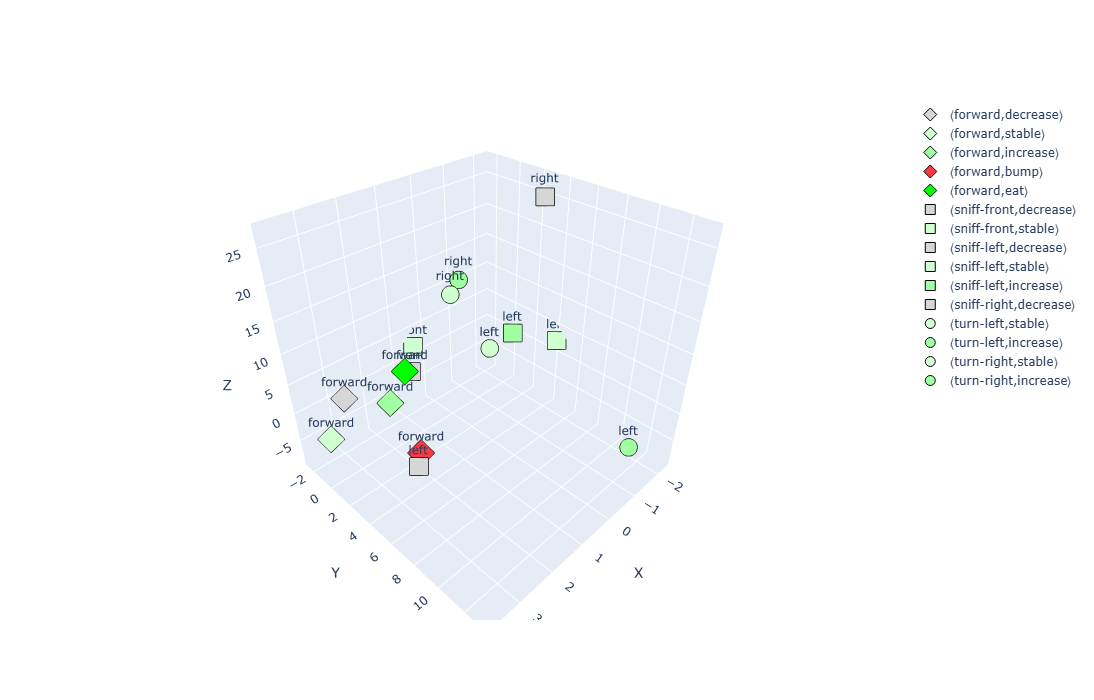

In [25]:
# Look if for the body model

group_axes_direction = {
    "direction_forward": df.index[df['direction'] == "front"].tolist(), 
    "direction_left": df.index[df['direction'] == "left"].tolist(), 
    "direction_right": df.index[df['direction'] == "right"].tolist(),
}
token_labels =  df['label'].tolist()
all_tokens = df.index.tolist()

# embedding_weight = model.embedding.weight
projected = project_embeddings_to_3D(model.embedding.weight, group_axes_direction)
plotly_embedding(projected, [token_labels[i] for i in all_tokens], all_tokens)

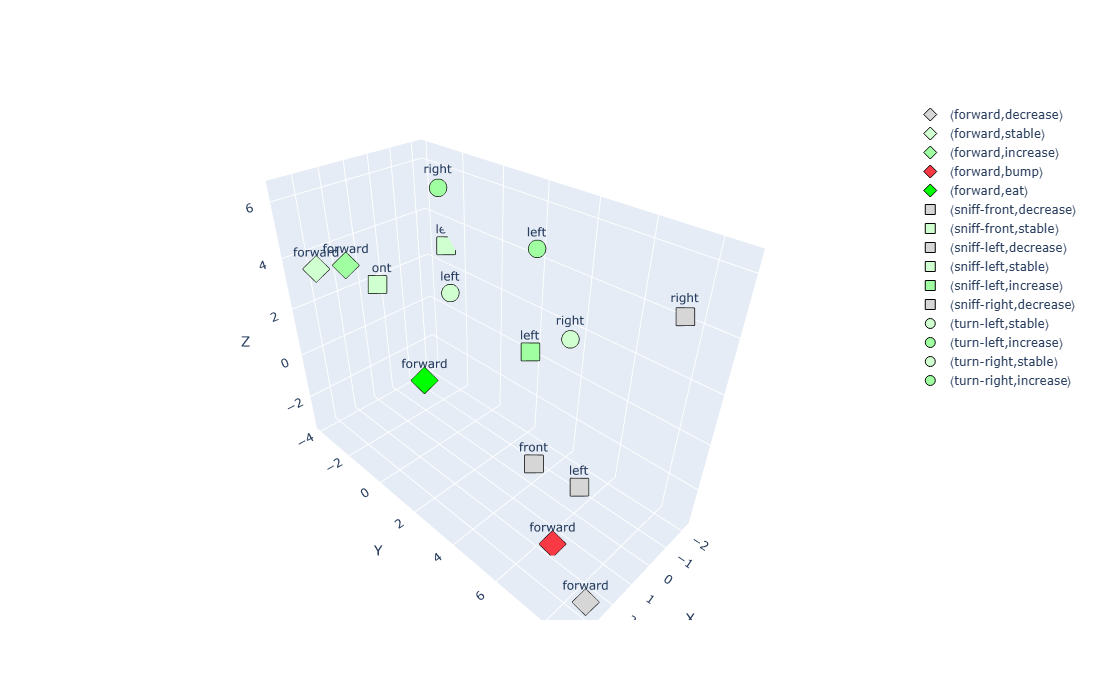

In [26]:
# Look for the object model

group_axes_object = {
    "direction_forward": df.index[df['direction'] == "front"].tolist(), 
    "wall": df.index[df['object'] == "wall"].tolist() , 
    "empty": df.index[df['object'] == "empty"].tolist() ,
    # "eat": df.index[df['object'] == "eat"].tolist()
}
projected = project_embeddings_to_3D(model.embedding.weight, group_axes_object)
plotly_embedding(projected, [token_labels[i] for i in all_tokens], all_tokens)

# Analysis

The visualization of the embedding space reveals the emergence of semantics: tokens that have similar meaning are clustered together in some projections of the embedding space. 

![img/04_embedding_caption.svg](img/04_embedding_caption.svg)

_Figure 1: Projections of the token embedding space showing clusters of tokens related to sensorimotor loops on the right (a1), front (a2), and left (a3) sides of the agent, and smelling the target (b1) or wall (b2)._